# Рубежный контроль №1 (весна 2025 года)
**Студент:** Ларкин Борис Владимирович

**Группа:** ИУ5-61Б

|Номер задания|Номер задачи|Номер набора данных, указанного в задаче|
|:---:|:---:|:---:|
|9|2|1|

**Дополнительные требования:**
Для пары произвольных колонок данных построить график "Диаграмма рассеяния".

**Задача №2**  
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

**Датасет**
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import *
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import LabelEncoder
%matplotlib inline 
sns.set(style="ticks")

## Загрузка данных

In [2]:
iris = load_iris()
data = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])
data['class'] = iris.target
data = data.drop('target', axis=1)

## Основные характеристики датасета

In [3]:
# Первые 5 строк датасета
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Размер датасета - 1025 строк, 14 колонок
data.shape

(150, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [6]:
total_count = data.shape[0]

In [7]:
data.isnull().sum() # в датасете отсутствуют пропуски 

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
class                0
dtype: int64

In [8]:
# Добавим искусственные пропуски для демонстрации
np.random.seed(42)
mask_quantitative = np.random.choice([True, False], size=len(data), p=[0.1, 0.9])
mask_categorical = np.random.choice([True, False], size=len(data), p=[0.1, 0.9])

In [9]:
# Создаем пропуски в количественном признаке (sepal length)
data.loc[mask_quantitative, 'sepal length (cm)'] = np.nan

# Создаем искусственный категориальный признак и добавляем в него пропуски
data['flower_color'] = np.random.choice(['red', 'blue', 'yellow'], size=len(data))
data.loc[mask_categorical, 'flower_color'] = np.nan

In [10]:
print("Данные с пропусками:")
print(data.isnull().sum())

Данные с пропусками:
sepal length (cm)    18
sepal width (cm)      0
petal length (cm)     0
petal width (cm)      0
class                 0
flower_color         16
dtype: int64


In [11]:
# Определим уникальные значения для категориальных признаков
data['flower_color'].unique()

array(['red', 'blue', 'yellow', nan], dtype=object)

In [12]:
data['class'].unique()

array([0, 1, 2])

Целевой признак является бинарным; содержит значения 0, 1 и 2.

## Обработка пустых значений

Категориальный признак

In [13]:
temp_null_count = data[data['flower_color'].isnull()].shape[0]
dt = str(data['flower_color'].dtype)
temp_perc = round((temp_null_count / total_count) * 100.0, 2)
print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format('flower_color', dt, temp_null_count, temp_perc))

Колонка flower_color. Тип данных object. Количество пустых значений 16, 10.67%.


In [14]:
# Обработка пропусков в категориальном признаке (наиболее частый класс)
categorical_imputer = SimpleImputer(strategy='most_frequent')
data['flower_color'] = categorical_imputer.fit_transform(
    data[['flower_color']]).flatten()

data[['flower_color']]

,flower_color
0,red
1,blue
2,yellow
3,yellow
4,yellow
...,...
145,yellow
146,red
147,blue
148,red


Количественный признак

In [15]:
temp_null_count = data[data['sepal length (cm)'].isnull()].shape[0]
dt = str(data['sepal length (cm)'].dtype)
temp_perc = round((temp_null_count / total_count) * 100.0, 2)
print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format('sepal length (cm)', dt, temp_null_count, temp_perc))

Колонка sepal length (cm). Тип данных float64. Количество пустых значений 18, 12.0%.


In [16]:
# Обработка пропусков в количественном признаке (медиана)
quantitative_imputer = SimpleImputer(strategy='median')
data['sepal length (cm)'] = quantitative_imputer.fit_transform(
    data[['sepal length (cm)']])

data[['sepal length (cm)']]

,sepal length (cm)
0,5.10
1,4.90
2,4.70
3,4.60
4,5.00
...,...
145,5.75
146,6.30
147,6.50
148,5.75


Повторная проверка пустых значений

In [17]:
print("\nДанные после обработки пропусков:")
print(data.isnull().sum())


Данные после обработки пропусков:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
class                0
flower_color         0
dtype: int64


## Подготовка к использованию в модели

In [18]:
# Признаки для построения моделей
features = ['sepal length (cm)', 'sepal width (cm)', 
            'petal length (cm)', 'petal width (cm)'
            ]
iris_class = 'class'

In [19]:
data[features].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.832000,3.057333,3.758000,1.199333
std,0.778147,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.200000,2.800000,1.600000,0.300000
50%,5.750000,3.000000,4.350000,1.300000
75%,6.300000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [20]:
data[iris_class].unique()

array([0, 1, 2])

## Диаграммы рассеивания

Позволяют построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

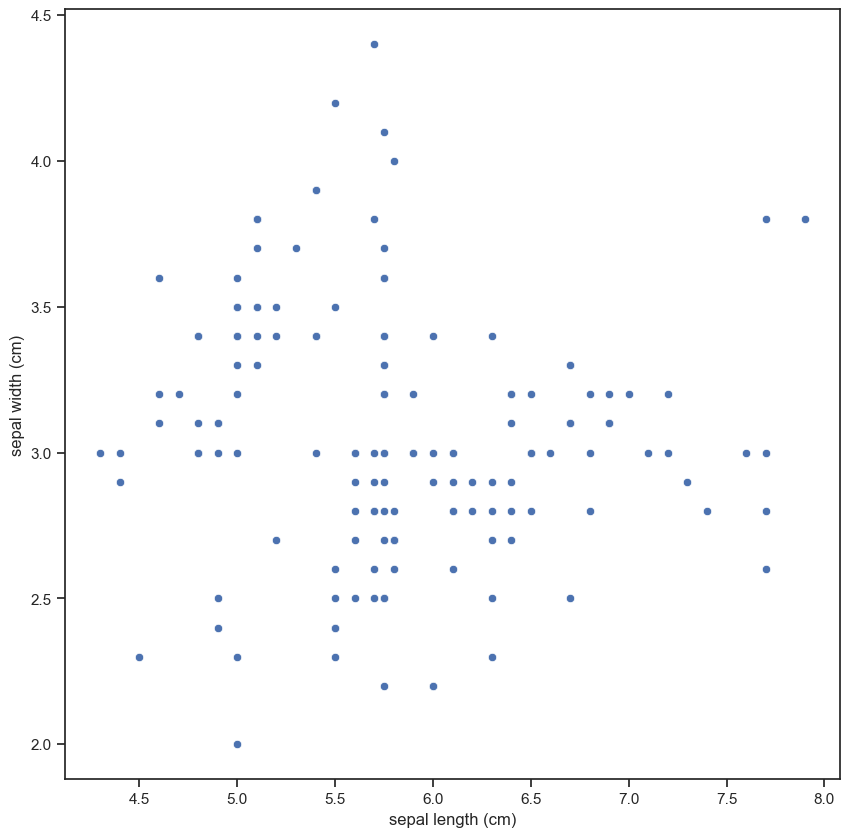

In [21]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='sepal length (cm)', y='sepal width (cm)', data=data)

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

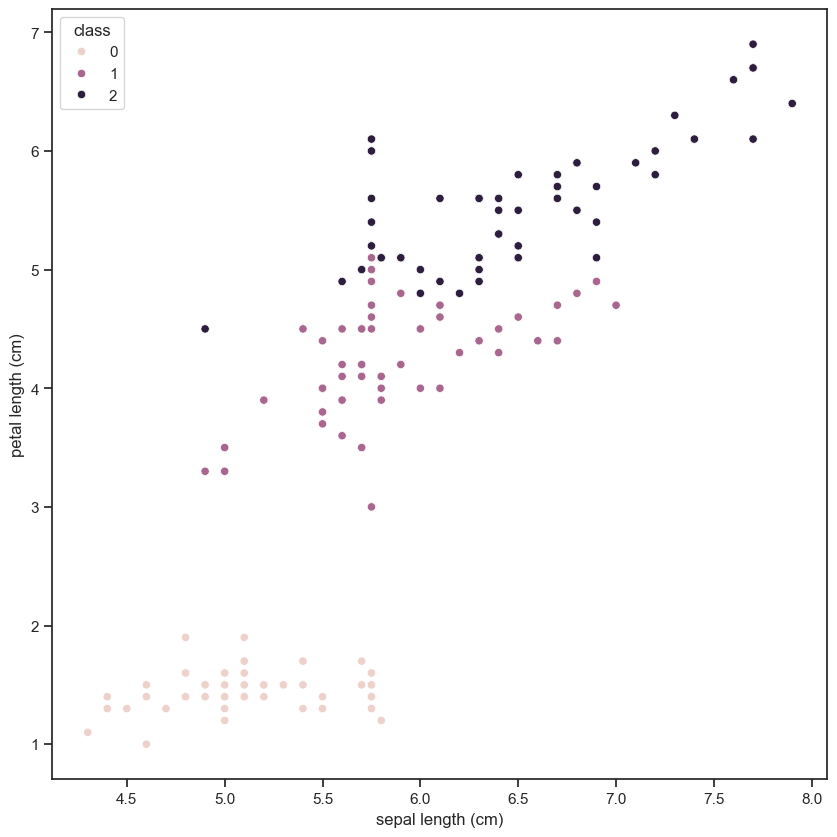

In [22]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax,x='sepal length (cm)', y='petal length (cm)', data=data, hue='class')

## Ответы на вопросы

### Способы обработки пропусков

Для качественного и количественного признаков была исользована методика импутации данных - "внедрения значений".

Процесс импутации - это замещение ошибочных, противоречивых и отсутствующих ответов в процессе редактирования данных другими ответами - значениями показателей. Стратегия проведения импутации определяется заранее при подготовке методологии проведения статистического наблюдения.

Для количественного признака (sepal length) использована стратегия медианы (strategy='median').

Причины выбора:

1. Медиана устойчива к выбросам
2. Сохраняет распределение признака
3. Не искажает статистические свойства данных

Для категориального признака (flower_color) использована стратегия наиболее частого значения (strategy='most_frequent').

Причины выбора:

1. Простота реализации
2. Минимальное искажение данных

### Признаки для построения моделей

Выбранные признаки (features):

- sepal length (cm) - количественный;

- sepal width (cm) - количественный;

- petal length (cm) - количественный;

- petal width (cm) - количественный;

Целевой признак:

- class_enc - категориальный, приведенный к норм. виду.


Все оригинальные признаки из датасета Iris:

Эти признаки исторически показывают хорошую разделимость классов:

1. Содержат информацию о размерах цветка, что напрямую связано с видом ириса

2. Имеют высокую корреляцию с целевой переменной

Искусственный категориальный признак (flower_color) добавлен для демонстрации работы с разными типами данных, его использование в моделях нельзя назвать целесообразным.

Исключены:

1. Необработанные категориальные признаки (требуют кодирования)

2. Признаки с низкой вариативностью

3. Признаки с высокой корреляцией между собой

## Выводы

После проведения замены пустых значений модель может быть построена.